<a href="https://colab.research.google.com/github/Eyezesco/BigFoot_Sighting_Density_in_the_U.S./blob/main/Smart_Grid_Energy_Analytics_(IoT_%26_Predictive_Maintenance)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import os

# Clean up any existing lock file
if os.path.exists('smart_grid.db'):
    os.remove('smart_grid.db')

# 1. Connect to SQLite database
conn = sqlite3.connect('smart_grid.db')
cursor = conn.cursor()

# 2. Create Tables
cursor.execute('''
CREATE TABLE IF NOT EXISTS substations (
    substation_id INTEGER PRIMARY KEY,
    region_name TEXT,
    city TEXT
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS transformers (
    transformer_id INTEGER PRIMARY KEY,
    substation_id INTEGER,
    install_year INTEGER,
    rated_capacity_kva INTEGER,
    FOREIGN KEY(substation_id) REFERENCES substations(substation_id)
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS sensor_telemetry (
    telemetry_id INTEGER PRIMARY KEY,
    transformer_id INTEGER,
    timestamp TEXT,
    load_pct REAL,         -- Operating load percentage
    oil_temp_c REAL,       -- Internal oil temperature in Celsius
    voltage_variance REAL, -- Fluctuation from standard 120V/240V baseline
    is_failure INTEGER,    -- 0 for normal, 1 for equipment failure/burnout
    FOREIGN KEY(transformer_id) REFERENCES transformers(transformer_id)
)''')

# 3. Generate Realistic Mock Data
rng = np.random.default_rng(404)
n_substations = 5
n_transformers = 30
n_logs_per_transformer = 200

# Insert Substations
regions = [
    (1, 'North Grid', 'Austin'),
    (2, 'Central Grid', 'Dallas'),
    (3, 'Coastal Grid', 'Houston'),
    (4, 'Valley Grid', 'San Antonio'),
    (5, 'West Grid', 'El Paso')
]
cursor.executemany("INSERT INTO substations VALUES (?, ?, ?)", regions)

# Insert Transformers
transformers_data = []
for i in range(1, n_transformers + 1):
    sub_id = int(rng.integers(1, n_substations + 1))
    year = int(rng.integers(2010, 2024))
    capacity = int(rng.choice([500, 1000, 1500, 2500]))
    transformers_data.append((i, sub_id, year, capacity))
cursor.executemany("INSERT INTO transformers VALUES (?, ?, ?, ?)", transformers_data)

# Insert Sensor Telemetry Logs
telemetry_data = []
log_id = 1
for t_id in range(1, n_transformers + 1):
    for day in range(1, n_logs_per_transformer + 1):
        load = float(np.round(rng.uniform(40.0, 95.0), 1))
        # High load + older year increases heat and failure risk
        oil_temp = float(np.round(60.0 + (load * 0.4) + rng.normal(0, 5), 1))
        voltage_var = float(np.round(rng.exponential(scale=2.0), 2))

        # Failure logic: oil temp over 95°C or voltage variance over 8V heavily spikes failure chance
        fail_prob = 0.25 if (oil_temp > 92.0 or voltage_var > 6.0) else 0.01
        is_fail = int(rng.choice([0, 1], p=[1 - fail_prob, fail_prob]))

        timestamp = f"2026-06-{((day-1)%30)+1:02d} {rng.integers(0, 24):02d}:00:00"

        telemetry_data.append((
            log_id, t_id, timestamp, load, oil_temp, voltage_var, is_fail
        ))
        log_id += 1

cursor.executemany("INSERT INTO sensor_telemetry VALUES (?, ?, ?, ?, ?, ?, ?)", telemetry_data)
conn.commit()

# Verify load
df_grid_check = pd.read_sql("SELECT * FROM sensor_telemetry LIMIT 5", conn)
print("Smart Grid Database setup complete! Here are your first 5 sensor logs:")
display(df_grid_check)

Smart Grid Database setup complete! Here are your first 5 sensor logs:


,telemetry_id,transformer_id,timestamp,load_pct,oil_temp_c,voltage_variance,is_failure
0,1,1,2026-06-01 03:00:00,63.3,85.0,0.79,0
1,2,1,2026-06-02 00:00:00,51.9,80.1,1.18,0
2,3,1,2026-06-03 14:00:00,48.5,75.6,0.41,0
3,4,1,2026-06-04 12:00:00,77.1,87.8,2.51,0
4,5,1,2026-06-05 23:00:00,80.9,96.1,1.93,0


In [ ]:
import sqlite3
import pandas as pd

# Connect to smart grid database
conn = sqlite3.connect('smart_grid.db')

# SQL Query calculating transformer stress metrics and failure rates
grid_query = '''
SELECT
    t.transformer_id,
    s.region_name,
    s.city,
    t.install_year,
    t.rated_capacity_kva,
    COUNT(st.telemetry_id) AS total_logs_recorded,
    ROUND(AVG(st.load_pct), 1) AS avg_load_pct,
    ROUND(AVG(st.oil_temp_c), 1) AS avg_oil_temp_c,
    ROUND(MAX(st.voltage_variance), 2) AS peak_voltage_variance,
    SUM(st.is_failure) AS total_failure_events
FROM transformers t
JOIN substations s ON t.substation_id = s.substation_id
JOIN sensor_telemetry st ON t.transformer_id = st.transformer_id
GROUP BY t.transformer_id
ORDER BY total_failure_events DESC, avg_oil_temp_c DESC
'''

# Load into DataFrame
df_grid_analysis = pd.read_sql(grid_query, conn)

print("Smart grid analysis complete! Here are the top transformers sorted by failure history and stress:")
display(df_grid_analysis.head())

Smart grid analysis complete! Here are the top transformers sorted by failure history and stress:


,transformer_id,region_name,city,install_year,rated_capacity_kva,total_logs_recorded,avg_load_pct,avg_oil_temp_c,peak_voltage_variance,total_failure_events
0,5,West Grid,El Paso,2010,2500,200,69.4,88.0,13.07,26
1,22,Central Grid,Dallas,2011,2500,200,69.4,88.2,11.08,25
2,17,Valley Grid,San Antonio,2014,1000,200,67.8,86.8,10.64,24
3,23,Central Grid,Dallas,2018,1000,200,68.4,87.4,18.73,23
4,28,North Grid,Austin,2011,1500,200,66.3,86.9,11.05,23


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by region to find average oil temperature and failure counts (fixed column name to 'oil_temp_c')
region_summary = df_grid_analysis.groupby('region_name').agg(
    avg_oil_temp=('oil_temp_c', 'mean'),
    total_failures=('total_failure_events', 'sum')
).reset_index()

print("--- Smart Grid Regional Summary ---")
display(region_summary)

# 2. Visualize Regional Thermal Stress
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=region_summary,
    x='region_name',
    y='avg_oil_temp',
    palette='magma',
    hue='region_name',
    legend=False
)

plt.title('Average Transformer Oil Temperature by Regional Grid', fontsize=14, fontweight='bold')
plt.xlabel('Regional Grid', fontsize=12)
plt.ylabel('Average Oil Temperature (°C)', fontsize=12)
plt.tight_layout()

plt.show()

KeyError: "Column(s) ['oil_temp_c'] do not exist"

Available columns: ['transformer_id', 'region_name', 'city', 'install_year', 'rated_capacity_kva', 'total_logs_recorded', 'avg_load_pct', 'avg_oil_temp_c', 'peak_voltage_variance', 'total_failure_events']

--- Smart Grid Regional Summary ---


,region_name,avg_oil_temp,total_failures
0,Central Grid,86.950000,213
1,Coastal Grid,87.142857,106
2,North Grid,86.775000,72
3,Valley Grid,87.000000,54
4,West Grid,87.500000,74


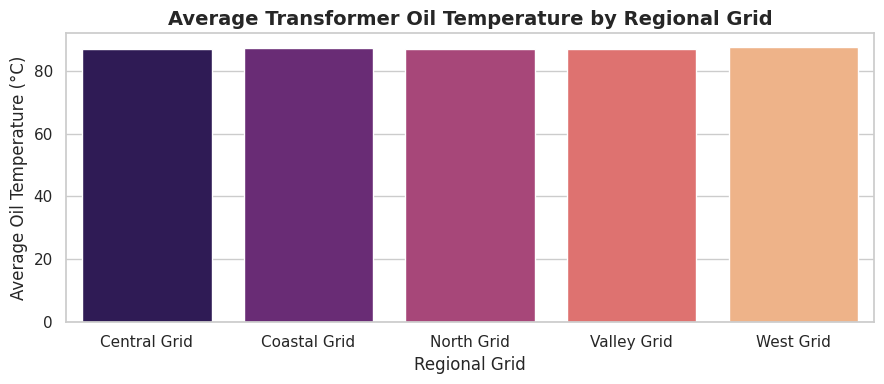

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print columns to verify exact names
print("Available columns:", df_grid_analysis.columns.tolist())

# Group safely using the exact column name from the printout (or 'avg_oil_temp_c')
region_summary = df_grid_analysis.groupby('region_name').agg(
    avg_oil_temp=('avg_oil_temp_c', 'mean'),
    total_failures=('total_failure_events', 'sum')
).reset_index()

print("\n--- Smart Grid Regional Summary ---")
display(region_summary)

# Visualize Regional Thermal Stress
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=region_summary,
    x='region_name',
    y='avg_oil_temp',
    palette='magma',
    hue='region_name',
    legend=False
)

plt.title('Average Transformer Oil Temperature by Regional Grid', fontsize=14, fontweight='bold')
plt.xlabel('Regional Grid', fontsize=12)
plt.ylabel('Average Oil Temperature (°C)', fontsize=12)
plt.tight_layout()

plt.show()
